# Kinetic Energy Analysis of Projectile Motion

# Ojective 
To compare kinetic energy variation over time: 
-With air reistance 
-Without air resistance 



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Simulation

In [73]:
def projectile_airdrag(v0=20,theta=45,k=0.05,dt=0.01):
    instant_time = [0]
    x,y = [0],[0]
    g = 9.8
    mass = 10
    K = [0.5*mass*v0**2]
    P = [mass * g * y[0]]
    steps = 0
    mx_steps = 100000
    time = 0
    
    mx_steps = 100000
    time = 0
   
    theta_t = np.radians(theta)
    vx = v0 * np.cos(theta_t)
    vy = v0 * np.sin(theta_t)
    max_height = y[-1]
    range =      x[-1]
    velocity= [v0]
    v = np.sqrt(vx**2 + vy**2)     #this is inital v

    while y[-1] >= 0 and steps < mx_steps :
        #computing acceleration
        ax = -k * v * vx
        ay = -g - k* v * vy
        
        #updating the velocity 
        vx += ax * dt
        vy += ay * dt

        
        

       
        #update the position 
        x.append(x[-1] + vx*dt)
        y.append(y[-1] + vy*dt)
        
        #update the velocity
        v = np.sqrt(vx**2 + vy**2)
        velocity.append(v) 
         
        #updating the kinetic energy 
        K_E = 1/2 * mass * (v) ** 2 
        K.append(K_E) 

        #updating the potential energy 
        P_E = mass * (g) * y[-1] 
        P.append(P_E)

        #updating the total energy  
        Total_E = [x + y for x,y in zip(K,P)] 
        

        if y[-1] > max_height:
            max_height = y[-1]

        if x [-1] > range:
            range = x[-1]    

        steps += 1
        time += dt
        instant_time.append(time)
        
        
    
        if steps == mx_steps:
            print("ValueErro: Some bug is in the code!")

        

    return {
        
        "time": time,
        "height": max_height,
        "range" : range,
        "horizental": x,
        "vertical": y,
        "Kinetic_Energy": K,
        "Potential_Energy": P,
        "Total_Energy": Total_E,
        "inst_time": instant_time,
        "velocity" : velocity,
        "x_pos"    : x,
        "y_pos"    : y,

    }


## Run Experiment 

In [74]:
result = projectile_airdrag()
result2 = projectile_airdrag(v0=20,theta=45,k=0)




## Extract Data

In [75]:
KE_drag = result["Kinetic_Energy"]
KE_no_drag = result2["Kinetic_Energy"]
time = result['inst_time']
time2 = result2['inst_time']



## Visualization

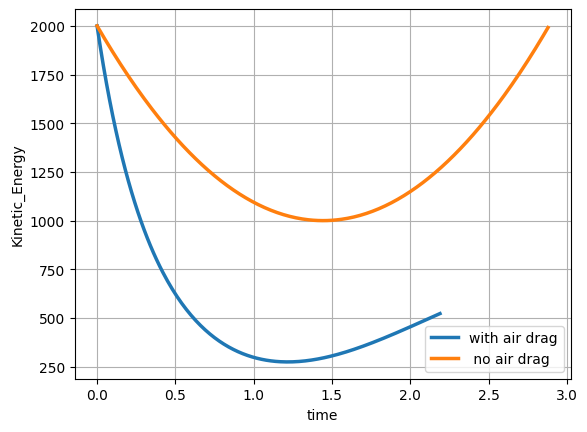

In [76]:
plt.plot(time,KE_drag,lw=2.5, label="with air drag")
plt.plot(time2,KE_no_drag,lw=2.5, label= ' no air drag')
plt.xlabel("time")
plt.ylabel("Kinetic_Energy")

plt.grid()
plt.legend()
plt.show()

## Energy loss Education 

In [77]:
energy_loss = KE_no_drag[-1] - KE_drag[-1]
print(KE_no_drag[-1])
print(KE_drag[-1])


print(f" Energy loss {energy_loss:.2f} jule")

1991.4945215581881
522.50666595162
 Energy loss 1468.99 jule


## Model analysis by Pandas

In [97]:
df_drag = pd.DataFrame({
    "time": result['inst_time'],
    "x"   : result['x_pos'],
    "y"   : result["y_pos"],
    "velocity": result["velocity"],
    "kinetic_energy": result["Kinetic_Energy"],
    "Potential_energy": result['Potential_Energy'],
    "Total_energy"    : result['Total_Energy']
    
})
df_no_drag = pd.DataFrame({
    "time": result2['inst_time'],
    "x"   : result2['x_pos'],
    "y"   : result2["y_pos"],
    "velocity": result2["velocity"],
    "kinetic_energy": result2["Kinetic_Energy"],
    "Potential_energy": result2['Potential_Energy'],
    "Total_energy"    : result2['Total_Energy']
    
})

In [100]:
max_range = df_drag["x"].max()
max_height = df_drag["y"].max()
print(f" max range of projectile {max_range:.2f} and height {max_height:.2f}")

 max range of projectile 17.37 and height 5.93


##  Potential Energy Plot

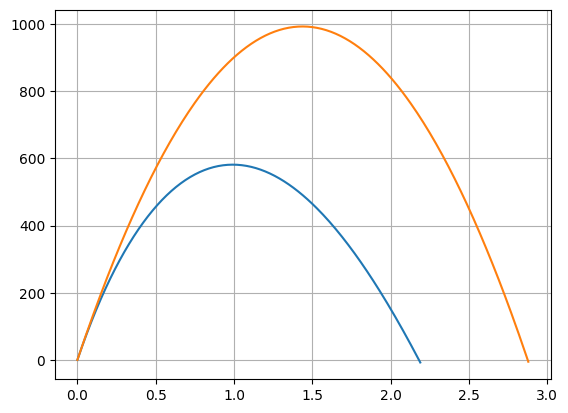

In [93]:
plt.plot(result["inst_time"],result["Potential_Energy"])
plt.plot(result2["inst_time"],result2["Potential_Energy"])
plt.xlabel = "time"
plt.ylabel = "Potential_energy"

plt.grid()
plt.show()


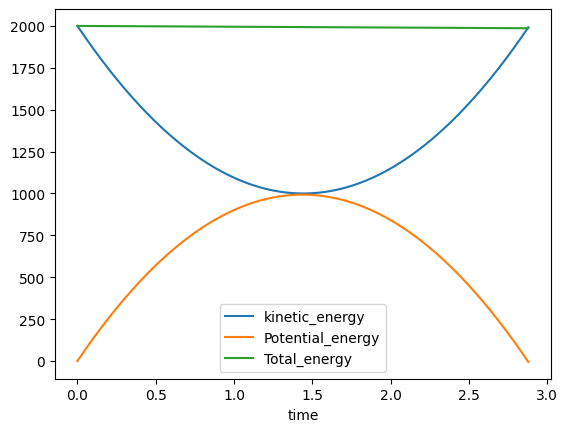

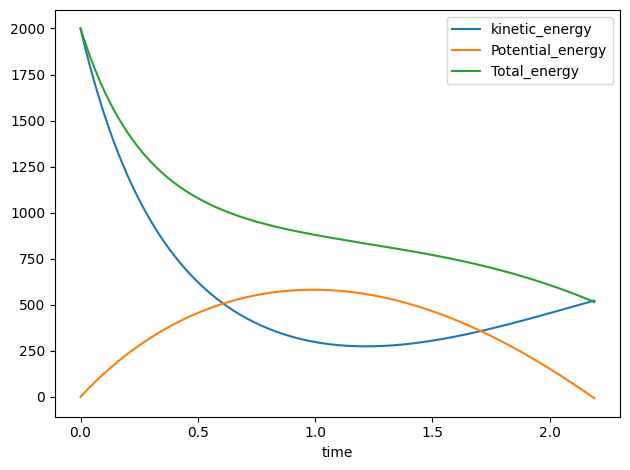

In [106]:
df_no_drag.plot(x='time', y =['kinetic_energy','Potential_energy','Total_energy'])
df_drag.plot(x='time', y=['kinetic_energy','Potential_energy', 'Total_energy'])

plt.tight_layout()
plt.show()